In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import OneHotEncoder

## Load Data

In [ ]:
# If running on colab you can download the data using gdown. Uncomment the below code.
# import gdown
# !gdown 1JTvMkEaR3AxqAagYzfLebnS_RavA7agR #x_train_img.npz
# !gdown 1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1 #x_test_img.npz
# !gdown 1tED7-ZgWT0ONtohOD1BCCrlTvXfQM6L0 #x_train.csv
# !gdown 1k36wEmeaks1pg2Q5t3aW3e24uxDaUll8 #x_test.csv
# !gdown 1J2fEdFSfZnTJ9YwxNnB8qDEOrIOkqbkg #y_train.csv

Downloading...
From (original): https://drive.google.com/uc?id=1JTvMkEaR3AxqAagYzfLebnS_RavA7agR
From (redirected): https://drive.google.com/uc?id=1JTvMkEaR3AxqAagYzfLebnS_RavA7agR&confirm=t&uuid=b22c4b51-8d20-4fbe-a9e1-af6e30d032f4
To: /content/x_train_img.npz
100% 177M/177M [00:01<00:00, 142MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1
From (redirected): https://drive.google.com/uc?id=1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1&confirm=t&uuid=657ea919-c435-4d79-9897-e8c0aa3fe6fc
To: /content/x_test_img.npz
100% 44.4M/44.4M [00:00<00:00, 172MB/s]
Downloading...
From: https://drive.google.com/uc?id=1tED7-ZgWT0ONtohOD1BCCrlTvXfQM6L0
To: /content/x_train.csv
100% 160k/160k [00:00<00:00, 6.38MB/s]
Downloading...
From: https://drive.google.com/uc?id=1k36wEmeaks1pg2Q5t3aW3e24uxDaUll8
To: /content/x_test.csv
100% 40.3k/40.3k [00:00<00:00, 47.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1J2fEdFSfZnTJ9YwxNnB8qDEOrIOkqbkg
To: /content

In [ ]:
img_file = "x_train_img.npz"
metadata_file = "x_train.csv"
y_file = "y_train.csv"

In [ ]:
X_dev = pd.read_csv(metadata_file)
y_dev = pd.read_csv(y_file)
X_dev

,patient_id,img_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,fitspatrick,region,diameter_1,diameter_2,itch,grew,hurt,changed,bleed,elevation
0,PAT_620,PAT_620_001,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,3.0,NECK,6.0,5.0,True,True,False,True,True,True
1,PAT_388,PAT_388_002,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,1.0,FOREARM,5.0,5.0,True,True,False,False,True,True
2,PAT_518,PAT_518_003,False,True,GERMANY,ITALY,52,False,FEMALE,False,...,3.0,FACE,15.0,10.0,False,True,False,True,True,True
3,PAT_635,PAT_635_004,False,False,POMERANIA,POMERANIA,74,True,FEMALE,False,...,1.0,FACE,15.0,10.0,True,True,True,False,True,True
4,PAT_447,PAT_447_005,False,True,GERMANY,GERMANY,58,True,FEMALE,True,...,1.0,FOREARM,9.0,7.0,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1173,PAT_409,PAT_409_1470,True,False,POMERANIA,POMERANIA,66,False,MALE,True,...,2.0,EAR,20.0,15.0,True,False,True,False,True,True
1174,PAT_640,PAT_640_1471,False,False,POMERANIA,POMERANIA,41,True,MALE,False,...,2.0,FACE,9.0,5.0,True,UNK,True,UNK,True,True
1175,PAT_539,PAT_539_1472,False,False,POMERANIA,POMERANIA,43,True,FEMALE,True,...,2.0,FACE,9.0,5.0,True,UNK,False,UNK,True,True
1176,PAT_620,PAT_620_1473,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,3.0,CHEST,13.0,12.0,True,True,False,True,False,False


In [ ]:
# Function and code to load images
def load_img_data(file_path):
    with np.load(file_path) as data:
        img = data['images']
        ids = data['image_ids']
    print(f"Successfully loaded {img.shape[0]} images.")
    return img, ids

imgs, img_ids = load_img_data(img_file)
print(img_ids.shape, imgs.shape)

# Make sure the IDs match and are in the same order
assert np.all(img_ids == X_dev['img_id']), "Image IDs in metadata and image data do not match"

Successfully loaded 1178 images.
(1178,) (1178, 256, 256, 3)


<Axes: xlabel='count', ylabel='fine_label'>

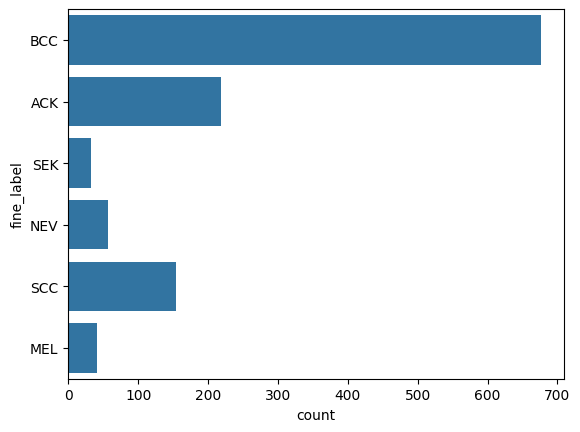

In [ ]:
# Plot the class balance
sns.countplot(y_dev["fine_label"])

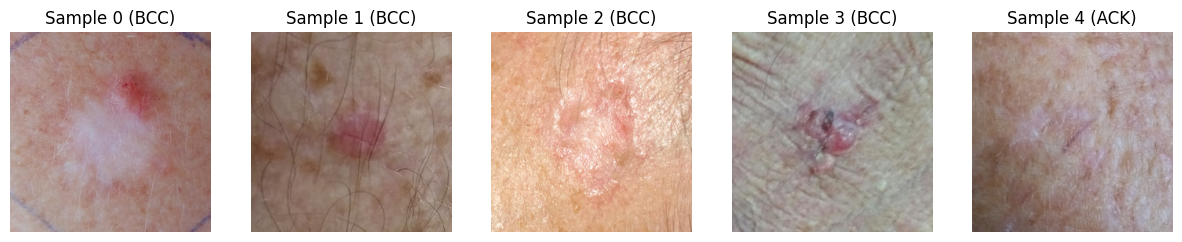

In [ ]:
# Show the first 5 images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    axes[i].imshow(imgs[i])
    axes[i].axis('off')
    axes[i].set_title(f"Sample {i} ({y_dev.iloc[i]["fine_label"]})")

plt.show()

## Encode Categorical Features

We'll convert all categorical features to one-hot encodings, and all binary features to 1/0.
We can auto-detect the binary features by looking for "True" and "False" (after manually looking through the data to confirm that's how these features are encoded.)

There also is a column labeled "gender". In publicly available datasets it can be especially tricky to figure out what a gender or sex column actually represents. Sometimes it's a patient's legal sex from government records, sometimes it's their biological sex from medical records, sometimes it's the clinician's assumption of the patient's gender, and sometimes it's the patient's self identified gender. The authors of this dataset provide a pdf of [the translated data collection instrument](https://pmc.ncbi.nlm.nih.gov/articles/instance/7479321/bin/mmc2.pdf) where we can see that gender is listed under "Questions About the Patient" and are phrased as questions the clinician would ask the patient directly. Therefore, in this case the gender column most likely represents patient self-identified gender.

In [ ]:
# These are the 3 columns in X that have categorical data.
# Everything else is binary or numeric.
categorical_cols = ['background_father', 'background_mother', 'region']

# Get all obvious true/false cols that aren't already true/false
for col in X_dev.select_dtypes(include=['object']):
    if X_dev[col].dropna().astype(str).str.contains('True|False').any():
        print(f"Automatically converting {col} to binary...")
        unmapped = X_dev[~X_dev[col].isin(['True','False'])][col].unique()
        print("The following values are being mapped to NaN in this column: ", unmapped)
        X_dev[col] = X_dev[col].map({'True': 1, 'False': 0, True: 1, False: 0})
        X_dev[col] = X_dev[col].map({'true': 1, 'false': 0})


X_dev['gender'] = X_dev['gender'].map({'MALE': 0, 'FEMALE': 1})

# Handle the categorical data
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_feats = encoder.fit_transform(X_dev[categorical_cols])
encoded_df = pd.DataFrame(
    encoded_feats,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_dev.index
)

# Drop original text columns and join the new numeric ones
X_dev = X_dev.drop(columns=categorical_cols).join(encoded_df)


Automatically converting itch to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting grew to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting hurt to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting changed to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting bleed to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting elevation to binary...
The following values are being mapped to NaN in this column:  ['UNK']


### Make age groups feature

In [ ]:
age_groups = pd.cut(
    X_dev['age'],
    bins=[0, 30, 60, 100],
    labels=['Young (<30)', 'Adult (30-60)', 'Senior (60+)']
)

## Handle Missing Data

In [ ]:
# First we'll calculate how much missing data there is
X_dev.isna().sum()

,0
patient_id,0
img_id,0
smoke,0
drink,0
age,0
pesticide,0
gender,0
skin_cancer_history,0
cancer_history,0
has_piped_water,0


In [ ]:
# Then we'll decide what to do. For now we'll just treat missing data as false,
# since it probably means that a patient didn't think the question was important or relevant.
X_dev = X_dev.fillna(0)
print(X_dev.columns.tolist())
X_dev.shape

# Convert all boolean columns to integers
bool_cols = X_dev.select_dtypes(include=['bool']).columns
X_dev[bool_cols] = X_dev[bool_cols].astype(int)

# Verify - should be all numeric now
print(X_dev.dtypes.value_counts())
print(X_dev.head())

print(X_dev.shape)
y_dev = y_dev['coarse_label']

X_dev['diameter_area'] = X_dev['diameter_1'] * X_dev['diameter_2']
#X_dev['ellipse_area'] = np.pi * X_dev['diameter_1'] * X_dev['diameter_2'] / 4



# Also convert y_dev if it's boolean


['patient_id', 'img_id', 'smoke', 'drink', 'age', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'diameter_1', 'diameter_2', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'background_father_AUSTRIA', 'background_father_BRASIL', 'background_father_BRAZIL', 'background_father_CZECH', 'background_father_GERMANY', 'background_father_ISRAEL', 'background_father_ITALY', 'background_father_NETHERLANDS', 'background_father_POLAND', 'background_father_POMERANIA', 'background_father_PORTUGAL', 'background_father_SPAIN', 'background_father_UNK', 'background_mother_BRAZIL', 'background_mother_GERMANY', 'background_mother_ITALY', 'background_mother_NETHERLANDS', 'background_mother_NORWAY', 'background_mother_POLAND', 'background_mother_POMERANIA', 'background_mother_PORTUGAL', 'background_mother_SPAIN', 'background_mother_UNK', 'region_ABDOMEN', 'region_ARM', 'region_BACK', 'region_CHEST', 'region_EAR', 'region_FACE'

## Your Code

You might want to revisit the above preprocessing steps for your Problem 2 model. You also might want to put some of the above code into functions to make it easier to apply to different datasets.

In [ ]:
X_dev = X_dev.drop(columns = ['patient_id', 'img_id'])
X_dev = X_dev.drop(columns = ['diameter_1', 'diameter_2'])



base_forest = sklearn.ensemble.RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    max_depth=16,
    min_samples_split=2,
    min_samples_leaf=1
    )


forest_hyperparameter_grid_by_name = dict(
    max_features=[3, 7, 10],
    max_depth=[16, 32, 64],
    min_samples_leaf=[1],
    n_estimators=[100],
    random_state=[101],
    )

forest_searcher = sklearn.model_selection.GridSearchCV(base_forest,
                                                       forest_hyperparameter_grid_by_name,
                                                       scoring="roc_auc",
                                                       cv=5,
                                                       return_train_score=True,
                                                       refit=False
                                                       )

forest_searcher.fit(X_dev, y_dev)

results = pd.DataFrame({
    'params': forest_searcher.cv_results_['params'],
    'mean_auroc': forest_searcher.cv_results_['mean_test_score'],
    'std_auroc': forest_searcher.cv_results_['std_test_score'],
    'rank': forest_searcher.cv_results_['rank_test_score']
})

# Sort by best AUROC
results = results.sort_values('mean_auroc', ascending=False)
print(results)



                                              params  mean_auroc  std_auroc  \
0  {'max_depth': 16, 'max_features': 3, 'min_samp...    0.874786   0.012616   
3  {'max_depth': 32, 'max_features': 3, 'min_samp...    0.861679   0.016754   
6  {'max_depth': 64, 'max_features': 3, 'min_samp...    0.861679   0.016754   
5  {'max_depth': 32, 'max_features': 10, 'min_sam...    0.861564   0.023733   
8  {'max_depth': 64, 'max_features': 10, 'min_sam...    0.861564   0.023733   
4  {'max_depth': 32, 'max_features': 7, 'min_samp...    0.857565   0.023536   
7  {'max_depth': 64, 'max_features': 7, 'min_samp...    0.857565   0.023536   
2  {'max_depth': 16, 'max_features': 10, 'min_sam...    0.855755   0.016135   
1  {'max_depth': 16, 'max_features': 7, 'min_samp...    0.855508   0.029234   

   rank  
0     1  
3     2  
6     2  
5     4  
8     4  
4     6  
7     6  
2     8  
1     9  


In [ ]:
test_base_forest = sklearn.ensemble.RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    max_depth=32,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=101,
    max_features = 3
    )

test_base_forest.fit(X_dev, y_dev)
importances = pd.DataFrame({
    'feature': X_dev.columns,
    'importance': test_base_forest.feature_importances_
}).sort_values('importance', ascending=False)

print(importances)

                          feature  importance
2                             age    0.211832
53                  diameter_area    0.159288
9                     fitspatrick    0.061105
41                    region_BACK    0.044290
5             skin_cancer_history    0.034911
3                       pesticide    0.034507
6                  cancer_history    0.032134
44                    region_FACE    0.028722
52                   region_THIGH    0.028288
4                          gender    0.027576
8               has_sewage_system    0.026070
1                           drink    0.024995
7                 has_piped_water    0.023974
46                 region_FOREARM    0.020000
50                    region_NOSE    0.018770
42                   region_CHEST    0.017482
20      background_father_GERMANY    0.016547
30      background_mother_GERMANY    0.016048
31        background_mother_ITALY    0.015472
0                           smoke    0.015118
39                 region_ABDOMEN 

In [ ]:
if hasattr(forest_searcher, 'cv_results_'):
    forest_search_results_df = pd.DataFrame(forest_searcher.cv_results_).copy()
    print("Grid search of %3d configurations done" % (forest_search_results_df.shape[0]))
    pd.set_option('display.precision', 4)
    forest_keys = ['param_max_depth', 'param_min_samples_leaf']
    forest_search_results_df.sort_values(forest_keys, inplace=True)
    forest_search_results_df[forest_keys + ['mean_train_score', 'mean_test_score', 'rank_test_score', 'mean_fit_time']]

print(forest_searcher.best_params_)

Grid search of   9 configurations done
{'max_depth': 16, 'max_features': 3, 'min_samples_leaf': 1, 'n_estimators': 100, 'random_state': 101}
